In [2]:
import os, sys
from transformers import RobertaTokenizer, RobertaConfig, Trainer, TrainingArguments
from safetensors import safe_open
import torch
import pandas as pd
import numpy as np
from datasets import Dataset, concatenate_datasets

sys.path.append("../")
from utils.parameters import *
from train_two_tower_model.two_tower_models import DualTowerForSequenceClassification_visual

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
config = RobertaConfig(
    vocab_size_1=9, # 9 for base, 10_000 for bpe
    vocab_size_2=10_000,
    hidden_size=256, # embedding size
    max_position_embeddings=128,
    num_decoder_layers=3,
    num_attention_heads=8,
    intermediate_size=3072,
    type_vocab_size=1,
    pad_token_id=3,
    bos_token_id=0,
    eos_token_id=1,
    position_embedding_type="relative_key",
)
# * tower model
tower_model = DualTowerForSequenceClassification_visual(config, is_pretrained=False)
tensors = {}
with safe_open(SAVED_MODEL_DIR_SEMI_V2+"_fold0/model.safetensors", framework="pt") as f:
    for k in f.keys():
        tensors[k] = f.get_tensor(k)
tower_model.load_state_dict(tensors)
tower_model.to(device)

tokenizer1 = RobertaTokenizer.from_pretrained(TOKEN_DIR_BASE)
tokenizer2 = RobertaTokenizer.from_pretrained(TOKEN_DIR_BPE)

In [4]:
CTRACT_DICT = {
    "CCC": 5,
    "CCCC": 6,
    "CCCCC": 7,
    "CCCCCC": 8,
    "CCCCCCC": 9,
    "CCCCCCCC": 10,
    "CCCCCCCCC": 11,
    "CCCCCCCCCC": 12,
    "CCCCCCCCCCC": 13,
    "CCCCCCCCCCCC": 14,
    "CCCCCCCCCCCCC": 15,
    "CCCCCCCCCCCCCC": 16,
    "CCCCCCCCCCCCCCC": 17,
}
CTRACT_ID_SET = set(CTRACT_DICT.values())
CTRACT_ID_TRANS = {
    5: 1, 6: 1, 7: 1, 8: 1, 9: 2,
    10: 2, 11: 2, 12: 2, 13: 3, 14: 3, 15: 3, 16: 3, 17: 4
}
DISCARD_IDS = {9, 10, 11, 12, 13, 14, 15, 16, 17}

def load_and_preprocess_data(file_path):
    samples = pd.read_csv(file_path, header=None, names=["sequence"])

    dataset = Dataset.from_pandas(samples)

    # Tokenize the sequences
    def tokenize_function(examples):
        tokens1 = tokenizer1(examples["sequence"], padding="max_length", max_length=MAX_LEN_BASE)
        tokens2 = tokenizer2(examples["sequence"], padding="max_length", max_length=MAX_LEN_BPE)
        filtered_tokens1 = list()
        filtered_tokens2 = list()
        for i, tokens in enumerate(tokens2["input_ids"]):
            obok = True
            ctract_num = 0
            for j in range(MAX_LEN_BPE):
                if tokens[j] in CTRACT_ID_SET:
                    ctract_num += 1
                    if ctract_num > 4 or tokens[j] in DISCARD_IDS:
                        obok = False
                        break
            if obok:
                filtered_tokens1.append(tokens1["input_ids"][i])
                filtered_tokens2.append(tokens2["input_ids"][i])
            else:
                filtered_tokens1.append([])
                filtered_tokens2.append([])
        return {"input_ids_1": filtered_tokens1, "input_ids_2": filtered_tokens2}

    tokenized_dataset = dataset.map(tokenize_function, batched=True)
    return tokenized_dataset

positive_dataset = load_and_preprocess_data(os.path.join(SAMPLES_PATH, "distinct_positive_samples_HEK293T.csv"))
negative_dataset = load_and_preprocess_data(os.path.join(SAMPLES_PATH, "distinct_negative_samples_HEK293T.csv"))
pseudo_pos_dataset = load_and_preprocess_data(os.path.join(PSEUDO_SAMPLES_PATH, "pseudo_positive_samples_HEK293T_v2.csv"))
pseudo_neg_dataset = load_and_preprocess_data(os.path.join(PSEUDO_SAMPLES_PATH, "pseudo_negative_samples_HEK293T_v2.csv"))

# 定义一个过滤函数
def filter_empty_input_ids(example):
    return len(example['input_ids_1']) > 0

# 使用 filter 方法删除 input_ids_1 为空列表的条目
filtered_positive_dataset = positive_dataset.filter(filter_empty_input_ids)
filtered_negative_dataset = negative_dataset.filter(filter_empty_input_ids)
filtered_pseudo_pos_dataset = pseudo_pos_dataset.filter(filter_empty_input_ids)
filtered_pseudo_neg_dataset = pseudo_neg_dataset.filter(filter_empty_input_ids)
print(len(filtered_positive_dataset))
print(len(filtered_negative_dataset))
print(len(filtered_pseudo_pos_dataset))
print(len(filtered_pseudo_neg_dataset))

combined_dataset = concatenate_datasets([filtered_positive_dataset, filtered_negative_dataset, filtered_pseudo_pos_dataset, filtered_pseudo_neg_dataset])
print(len(combined_dataset))


Map:   0%|          | 0/13708 [00:00<?, ? examples/s]

Map:   0%|          | 0/28717 [00:00<?, ? examples/s]

Map:   0%|          | 0/10276 [00:00<?, ? examples/s]

Map:   0%|          | 0/2137 [00:00<?, ? examples/s]

Filter:   0%|          | 0/13708 [00:00<?, ? examples/s]

Filter:   0%|          | 0/28717 [00:00<?, ? examples/s]

Filter:   0%|          | 0/10276 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2137 [00:00<?, ? examples/s]

5987
17517
4563
1199
29266


In [5]:
BATCH_SIZE = 1024
tower_model.eval()
with torch.no_grad():
    outputs_tower = torch.Tensor([])
    outputs_tower = outputs_tower.to(device)
    i = 0
    while batched_inputs := {"input_ids_1": torch.tensor(combined_dataset["input_ids_1"][i*BATCH_SIZE:(i+1)*BATCH_SIZE]).to(device), "input_ids_2": torch.tensor(combined_dataset["input_ids_2"][i*BATCH_SIZE:(i+1)*BATCH_SIZE]).to(device)}:
        if len(batched_inputs["input_ids_1"]) == 0:
            break
        outputs_tower = torch.cat((outputs_tower, tower_model(**batched_inputs).logits[:,1]), dim=0)
        i += 1

needed features:  
[1] C-tract length, 就是下面表格里的 stem_length  
[2] iM length, 就是下面表格里的 end  
[3] loop length,   
[4] middle loop length, 就是 loop2_length  
[5] longest side loop length, 就是 loop1_length 和 loop3_length 中的较大值  
[6] shortest side loop length, 就是 loop1_length 和 loop3_length 中的较小值  
[7] sum of two side loops,   
[8] longest loop length,   
[9] shortest loop length,   
[10] A density in iMs,   
[11] C density in iMs,   
[12] G density in iMs,   
[13] T density in iMs,   
[14] A density in loops,   
[15] C density in loops,   
[16] G density in loops,   
[17] T density in loops,   
[18] A density in middle loop,  
[19] C density in middle loop,   
[20] G density in middle loop,   
[21] T density in middle loop,   
[22] A density in longest side loop,   
[23] C density in longest side loop,   
[24] G density in longest side loop,   
[25] T density in longest side loop,   
[26] A density in shortest side loop,   
[27] C density in shortest side loop,   
[28] G density in shortest side loop,   
[29] T density in shortest side loop,   
[30] A density in two side loops,   
[31] C density in two side loops,   
[32] G density in two side loops,   
[33] T density in two side loops.  

In [6]:
# 将token_id转换为token
features33 = list()
for sample in combined_dataset:
    ids = sample["input_ids_2"]
    ctract_indices = list()
    for i, id in enumerate(ids):
        if id in CTRACT_ID_SET:
            ctract_indices.append(i)
            if len(ctract_indices) >= 4:
                break
    # c-tract, loop, c-tract, loop, c-tract, loop, c-tract
    imotif_seq = [tokenizer2.convert_ids_to_tokens(ids[ctract_indices[0]]),
                  "".join(tokenizer2.convert_ids_to_tokens(ids[ctract_indices[0]+1:ctract_indices[1]])),
                  tokenizer2.convert_ids_to_tokens(ids[ctract_indices[1]]),
                  "".join(tokenizer2.convert_ids_to_tokens(ids[ctract_indices[1]+1:ctract_indices[2]])),
                  tokenizer2.convert_ids_to_tokens(ids[ctract_indices[2]]),
                  "".join(tokenizer2.convert_ids_to_tokens(ids[ctract_indices[2]+1:ctract_indices[3]])),
                  tokenizer2.convert_ids_to_tokens(ids[ctract_indices[3]])]
    C_tract_len = min(len(imotif_seq[0]), len(imotif_seq[2]), len(imotif_seq[4]), len(imotif_seq[6]))
    im_len = sum([len(imotif_seq[i]) for i in range(7)])
    loop_len = len(imotif_seq[1]) + len(imotif_seq[3]) + len(imotif_seq[5])
    middle_loop_length = len(imotif_seq[3])
    longest_side_loop_length = max(len(imotif_seq[1]), len(imotif_seq[5]))
    shortest_side_loop_length = min(len(imotif_seq[1]), len(imotif_seq[5]))
    sum_of_two_side_loops = len(imotif_seq[1]) + len(imotif_seq[5])
    longest_loop_length = max(len(imotif_seq[1]), len(imotif_seq[3]), len(imotif_seq[5]))
    shortest_loop_length = min(len(imotif_seq[1]), len(imotif_seq[3]), len(imotif_seq[5]))
    iMs = "".join(imotif_seq) # is not a feature
    A_density_in_iMs = iMs.count("A") / len(iMs)
    C_density_in_iMs = iMs.count("C") / len(iMs)
    G_density_in_iMs = iMs.count("G") / len(iMs)
    T_density_in_iMs = iMs.count("T") / len(iMs)
    loops = imotif_seq[1]+imotif_seq[3]+imotif_seq[5] # is not a feature
    A_density_in_loops = loops.count("A") / len(loops)
    C_density_in_loops = loops.count("C") / len(loops)
    G_density_in_loops = loops.count("G") / len(loops)
    T_density_in_loops = loops.count("T") / len(loops)
    A_density_in_middle_loop = imotif_seq[3].count("A") / len(imotif_seq[3])
    C_density_in_middle_loop = imotif_seq[3].count("C") / len(imotif_seq[3])
    G_density_in_middle_loop = imotif_seq[3].count("G") / len(imotif_seq[3])
    T_density_in_middle_loop = imotif_seq[3].count("T") / len(imotif_seq[3])
    if len(imotif_seq[1]) >= len(imotif_seq[5]):
        longest_side_loop = imotif_seq[1] # is not a feature
        shortest_side_loop = imotif_seq[5] # is not a feature
    else:
        longest_side_loop = imotif_seq[5] # is not a feature
        shortest_side_loop = imotif_seq[1] # is not a feature
    A_density_in_longest_side_loop = longest_side_loop.count("A") / len(longest_side_loop)
    C_density_in_longest_side_loop = longest_side_loop.count("C") / len(longest_side_loop)
    G_density_in_longest_side_loop = longest_side_loop.count("G") / len(longest_side_loop)
    T_density_in_longest_side_loop = longest_side_loop.count("T") / len(longest_side_loop)
    A_density_in_shortest_side_loop = shortest_side_loop.count("A") / len(shortest_side_loop)
    C_density_in_shortest_side_loop = shortest_side_loop.count("C") / len(shortest_side_loop)
    G_density_in_shortest_side_loop = shortest_side_loop.count("G") / len(shortest_side_loop)
    T_density_in_shortest_side_loop = shortest_side_loop.count("T") / len(shortest_side_loop)
    two_side_loops = imotif_seq[1]+imotif_seq[5] # is not a feature
    A_density_in_two_side_loops = (two_side_loops).count("A") / len(two_side_loops)
    C_density_in_two_side_loops = (two_side_loops).count("C") / len(two_side_loops)
    G_density_in_two_side_loops = (two_side_loops).count("G") / len(two_side_loops)
    T_density_in_two_side_loops = (two_side_loops).count("T") / len(two_side_loops)
    features33.append([C_tract_len,
                        im_len,
                        loop_len,
                        middle_loop_length,
                        longest_side_loop_length,
                        shortest_side_loop_length,
                        sum_of_two_side_loops,
                        longest_loop_length,
                        shortest_loop_length,
                        A_density_in_iMs,
                        C_density_in_iMs,
                        G_density_in_iMs,
                        T_density_in_iMs,
                        A_density_in_loops,
                        C_density_in_loops,
                        G_density_in_loops,
                        T_density_in_loops,
                        A_density_in_middle_loop,
                        C_density_in_middle_loop,
                        G_density_in_middle_loop,
                        T_density_in_middle_loop,
                        A_density_in_longest_side_loop,
                        C_density_in_longest_side_loop,
                        G_density_in_longest_side_loop,
                        T_density_in_longest_side_loop,
                        A_density_in_shortest_side_loop,
                        C_density_in_shortest_side_loop,
                        G_density_in_shortest_side_loop,
                        T_density_in_shortest_side_loop,
                        A_density_in_two_side_loops,
                        C_density_in_two_side_loops,
                        G_density_in_two_side_loops,
                        T_density_in_two_side_loops])
features33 = np.array(features33)


计算皮尔逊相关系数 (Pearson Correlation Coefficient) 在 33 个特征features33 和 预测值outputs_tower 之间

In [7]:
def pearson_correlation(x, y):
    """
    计算两个数组的皮尔逊相关系数
    :param x: 数组1
    :param y: 数组2
    :return: 皮尔逊相关系数
    """
    if len(x) != len(y):
        raise ValueError("数组长度不一致")

    # 计算均值
    mean_x = np.mean(x)
    mean_y = np.mean(y)

    # 计算分子和分母
    numerator = np.sum((x - mean_x) * (y - mean_y))
    denominator = np.sqrt(np.sum((x - mean_x) ** 2) * np.sum((y - mean_y) ** 2))

    if denominator == 0:
        return 0

    return numerator / denominator

features33_names = [
    "[1] C-tract length",
    "[2] iM length",
    "[3] loop length",
    "[4] middle loop length",
    "[5] longest side loop length",
    "[6] shortest side loop length",
    "[7] sum of two side loops",
    "[8] longest loop length",
    "[9] shortest loop length",
    "[10] A density in iMs",
    "[11] C density in iMs",
    "[12] G density in iMs",
    "[13] T density in iMs",
    "[14] A density in loops",
    "[15] C density in loops",
    "[16] G density in loops",
    "[17] T density in loops",
    "[18] A density in middle loop", 
    "[19] C density in middle loop",
    "[20] G density in middle loop",
    "[21] T density in middle loop",
    "[22] A density in longest side loop",
    "[23] C density in longest side loop",
    "[24] G density in longest side loop",
    "[25] T density in longest side loop",
    "[26] A density in shortest side loop",
    "[27] C density in shortest side loop",
    "[28] G density in shortest side loop",
    "[29] T density in shortest side loop",
    "[30] A density in two side loops",
    "[31] C density in two side loops",
    "[32] G density in two side loops",
    "[33] T density in two side loops"
]

correlations = list()
for i in range(33):
    correlations.append([features33_names[i], pearson_correlation(features33[:,i], outputs_tower.cpu().numpy())])
correlations.sort(key=lambda x: x[1], reverse=True)
for i in range(33):
    print(f"{i+1}th: {correlations[i]}")

1th: ['[28] G density in shortest side loop', 0.41041924985340994]
2th: ['[16] G density in loops', 0.40394945630144835]
3th: ['[32] G density in two side loops', 0.3841627027432069]
4th: ['[20] G density in middle loop', 0.3456782363548295]
5th: ['[12] G density in iMs', 0.30950186230712506]
6th: ['[24] G density in longest side loop', 0.27940552599584784]
7th: ['[11] C density in iMs', 0.27128047026055585]
8th: ['[15] C density in loops', 0.10251841644169588]
9th: ['[23] C density in longest side loop', 0.0335440320079537]
10th: ['[31] C density in two side loops', 0.031103005540111844]
11th: ['[19] C density in middle loop', 0.019099625914204433]
12th: ['[1] C-tract length', 0.016414926218479033]
13th: ['[27] C density in shortest side loop', -0.056412422822002005]
14th: ['[4] middle loop length', -0.06785876387045754]
15th: ['[8] longest loop length', -0.10571114617680509]
16th: ['[25] T density in longest side loop', -0.13969827217437975]
17th: ['[21] T density in middle loop', -0

# 实验结果解释


## [1] C-tract length
在相同的实验条件下，长c束的iMs比短c束的iMs更稳定。
> [1] Fojtík, P. and Vorlícková, M. (2001) The fragile X chromosome (GCC) repeat folds into a DNA tetraplex at neutral pH. Nucleic Acids Res., 29 , 4684–4690.  
[2] Fleming, A.M. , Ding, Y. , Rogers, R.A. , Zhu, J. , Zhu, J. , Burton, A.D. , Carlisle, C.B. and Burrows, C.J. (2017) 4 n–1 is a “sweet spot” in DNA i-motif folding of 2 	 -deoxycytidine homopolymers. J. Am. Chem. Soc., 139 , 4682–4689.

当序列中每个胞嘧啶束至少含有5个C碱基时，可以在室温和生理pH下折叠成稳定的i-motif结构。
> Wright E P, Huppert J L, Waller Z A E. Identification of multiple genomic DNA sequences which form i-motif structures at neutral pH[J]. Nucleic acids research, 2017, 45(6): 2951-2959.

## [3] loop length
论文明确指出，C-tract 长度越长，i-motif 结构越稳定。
有研究指出短的环长度有利于i-motif稳定性。
> [1] Abou Assi H, Garavís M, González C, Damha MJ. i-Motif DNA: structural features and significance to cell biology. Nucleic Acids Res. 2018 Sep 19;46(16):8038-8056. doi: 10.1093/nar/gky735. PMID: 30124962; PMCID: PMC6144788.  

In general, under the same experimental conditions, the i-motif structure possessing a higher number of C:C+ base pairs would be more stable.  
However, there is a number of recent studies showing that class I i-motifs are stable at neutral or nearly neutral pH.  
> [2] Lieblein,A.L., Furtig,B. and Schwalbe,H. (2013) Optimizing the kinetics and thermodynamics of DNA i-motif folding. ChemBioChem., 14, 1226–1230.  
[3] Mir,B., Serrano,I., Buitrago,D., Orozco,M., Escaja,N. and Gonz´ alez,C. (2017) Prevalent sequences in the human genome can form Mini i-Motif structures at physiological pH. J. Am. Chem. Soc., 139, 13985–13988.

The results clearly show that the stability of the i-motif structure decreases as the length of the loop increases, a finding which is in contrast with statements made in the literature. One rationale for this observation, is as the loop length increases, the structure gains more flexibility, and therefore stabilising interactions become weaker.
> Gurung S P, Schwarz C, Hall J P, et al. The importance of loop length on the stability of i-motif structures[J]. Chemical Communications, 2015, 51(26): 5630-5632.

## 与预测概率正相关
### 与 iM-Seeker 结果一致
[11] C density in iMs  
[15] C density in loops  
[19] C density in middle loop  
[23] C density in longest side loop  
[31] C density in two side loops  
### 与 iM-Seeker 结果不一致
[12] G density in iMs  
[16] G density in loops  
[20] G density in middle loop  
[24] G density in longest side loop  
[28] G density in shortest side loop  
[32] G density in two side loops  

## 与预测概率负相关
### 与 iM-Seeker 结果一致
[4] middle loop length  
[5] longest side loop length  
[6] shortest side loop length  
[7] sum of two side loops  
[8] longest loop length  
[9] shortest loop length  
[10] A density in iMs  
[13] T density in iMs  
[14] A density in loops  
[18] A density in middle loop  
[22] A density in longest side loop  
[26] A density in shortest side loop  
[30] A density in two side loops  
### 与 iM-Seeker 结果不一致
[2] iM length  
[17] T density in loops  
[21] T density in middle loop  
[25] T density in longest side loop  
[27] C density in shortest side loop  
[29] T density in shortest side loop  
[33] T density in two side loops

In [8]:
# output to file
# with open("correlations.csv", "w") as f:
#     for i in range(33):
#         f.write(f"{i+1},{correlations[i][0]},{correlations[i][1]}\n")

# 论文
在本实验中，我们调查了im-seeker论文中提到的33个i-motif特征与双塔模型对 putative i-motif 的 folding status 的预测值的相关性。
这些特征包括 C-tract length, iM length, loop length, middle loop length, longest side loop length,
shortest side loop length, sum of two side loops, longest loop length, shortest loop length, 
A density in iMs, C density in iMs, G density in iMs, T density in iMs, A density in loops, 
C density in loops, G density in loops, T density in loops, A density in middle loop,
C density in middle loop, G density in middle loop, T density in middle loop, 
A density in longest side loop, C density in longest side loop, G density in longest side loop, 
T density in longest side loop, A density in shortest side loop, C density in shortest side loop, 
G density in shortest side loop, T density in shortest side loop, A density in two side loops, 
C density in two side loops, G density in two side loops, T density in two side loops.

如图所示。
我们统计了这些特征与预测值的皮尔逊相关系数，具有正相关性的特征代表它们的数值增加会使模型对i-motif的folding status的预测值增加，反之亦然。此外，由于iM-Seeker并未统计folding status分类模型中这些特征与预测值的相关性，所以我们也用同样的方法对reproduced_seeker模型中特征对预测值的相关性进行了统计。我们发现，双塔模型和reproduced_seeker模型中特征与预测值的相关性有很高的一致性。前几名最高的相关性的特征由"G density"相关的特征占据，而最后几个最低的相关性的特征由"A density"和"T density"占据。略微不同的是，双塔模型的33个特征与预测值的相关性的排序过渡的更平滑，而reproduced_seeker模型的33个特征与预测值的相关性的排序过渡的更陡峭（双塔模型的33个相关系数方差是0.054，而reproduced_seeker模型的则是0.110）。

如图所示。
我们还对比了双塔模型对特征与预测值的相关性的统计结果和iM-Seeker论文中用于预测strength of iM structures的回归模型对特征与预测值的相关性的统计结果。我们发现，两个模型间，大部分特征与预测值的相关性是一致的，但"G density"和"T density"相关的特征大部分是相反的。考虑到iM-Seeker中的回归模型的数据集和双塔模型的数据集是不同的，同时模型的任务也是不同的，所以这种差异是可以理解的。

此外，双塔模型的相关性分析显示C-tract长度与预测值正相关，而loop长度与预测值负相关，即较长的C-tract和较短的loop长度有助于iM的稳定性，这与先前的研究一致。

In [9]:
from scipy.stats import spearmanr

correlations2 = list()
for i in range(33):
    rho, pval = spearmanr(features33[:,i], outputs_tower.cpu().numpy())
    correlations2.append([features33_names[i], rho, pval])
correlations2.sort(key=lambda x: x[1], reverse=True)
for i in range(33):
    print(f"{i+1}th: {correlations2[i][0]}, Spearman rho = {correlations2[i][1]:.3f}, p = {correlations2[i][2]:.3e}")

1th: [16] G density in loops, Spearman rho = 0.403, p = 0.000e+00
2th: [32] G density in two side loops, Spearman rho = 0.361, p = 0.000e+00
3th: [28] G density in shortest side loop, Spearman rho = 0.342, p = 0.000e+00
4th: [20] G density in middle loop, Spearman rho = 0.311, p = 0.000e+00
5th: [12] G density in iMs, Spearman rho = 0.307, p = 0.000e+00
6th: [11] C density in iMs, Spearman rho = 0.290, p = 0.000e+00
7th: [24] G density in longest side loop, Spearman rho = 0.248, p = 0.000e+00
8th: [15] C density in loops, Spearman rho = 0.109, p = 3.533e-78
9th: [23] C density in longest side loop, Spearman rho = 0.037, p = 2.270e-10
10th: [31] C density in two side loops, Spearman rho = 0.036, p = 1.237e-09
11th: [1] C-tract length, Spearman rho = -0.000, p = 9.825e-01
12th: [19] C density in middle loop, Spearman rho = -0.001, p = 8.892e-01
13th: [27] C density in shortest side loop, Spearman rho = -0.088, p = 1.469e-51
14th: [4] middle loop length, Spearman rho = -0.101, p = 8.997e-

In [10]:
from sklearn.feature_selection import mutual_info_regression

correlations_mi1 = mutual_info_regression(features33, outputs_tower.cpu().numpy())
correlations_mi = list()
for i in range(33):
    correlations_mi.append([features33_names[i], correlations_mi1[i]])
correlations_mi.sort(key=lambda x: x[1], reverse=True)
for i in range(33):
    print(f"{i+1}th: {correlations_mi[i][0]}, MI = {correlations_mi[i][1]:.3f}")


1th: [16] G density in loops, MI = 0.191
2th: [32] G density in two side loops, MI = 0.151
3th: [10] A density in iMs, MI = 0.150
4th: [12] G density in iMs, MI = 0.148
5th: [14] A density in loops, MI = 0.148
6th: [2] iM length, MI = 0.139
7th: [8] longest loop length, MI = 0.134
8th: [28] G density in shortest side loop, MI = 0.133
9th: [3] loop length, MI = 0.133
10th: [11] C density in iMs, MI = 0.130
11th: [17] T density in loops, MI = 0.116
12th: [30] A density in two side loops, MI = 0.113
13th: [20] G density in middle loop, MI = 0.112
14th: [13] T density in iMs, MI = 0.103
15th: [15] C density in loops, MI = 0.100
16th: [5] longest side loop length, MI = 0.094
17th: [7] sum of two side loops, MI = 0.092
18th: [24] G density in longest side loop, MI = 0.091
19th: [33] T density in two side loops, MI = 0.090
20th: [22] A density in longest side loop, MI = 0.083
21th: [31] C density in two side loops, MI = 0.072
22th: [18] A density in middle loop, MI = 0.068
23th: [26] A densit

In [11]:
correlation_pearson_dict = {i[0]:i[1] for i in correlations}
correlation_spearman_dict = {i[0]:[i[1],i[2]] for i in correlations2}
correlation_mi_dict = {i[0]:i[1] for i in correlations_mi}

with open("./imtt_importance.csv", 'w') as f:
    # feature_name, spearman, p, mi, pearson
    f.write("feature_name,spearman,p,mi,pearson\n")
    for i in range(33):
        f.write(f"{features33_names[i]},{correlation_spearman_dict[features33_names[i]][0]},{correlation_spearman_dict[features33_names[i]][1]},{correlation_mi_dict[features33_names[i]]},{correlation_pearson_dict[features33_names[i]]}\n")

0.05453755797738694
0.10777793878226444


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


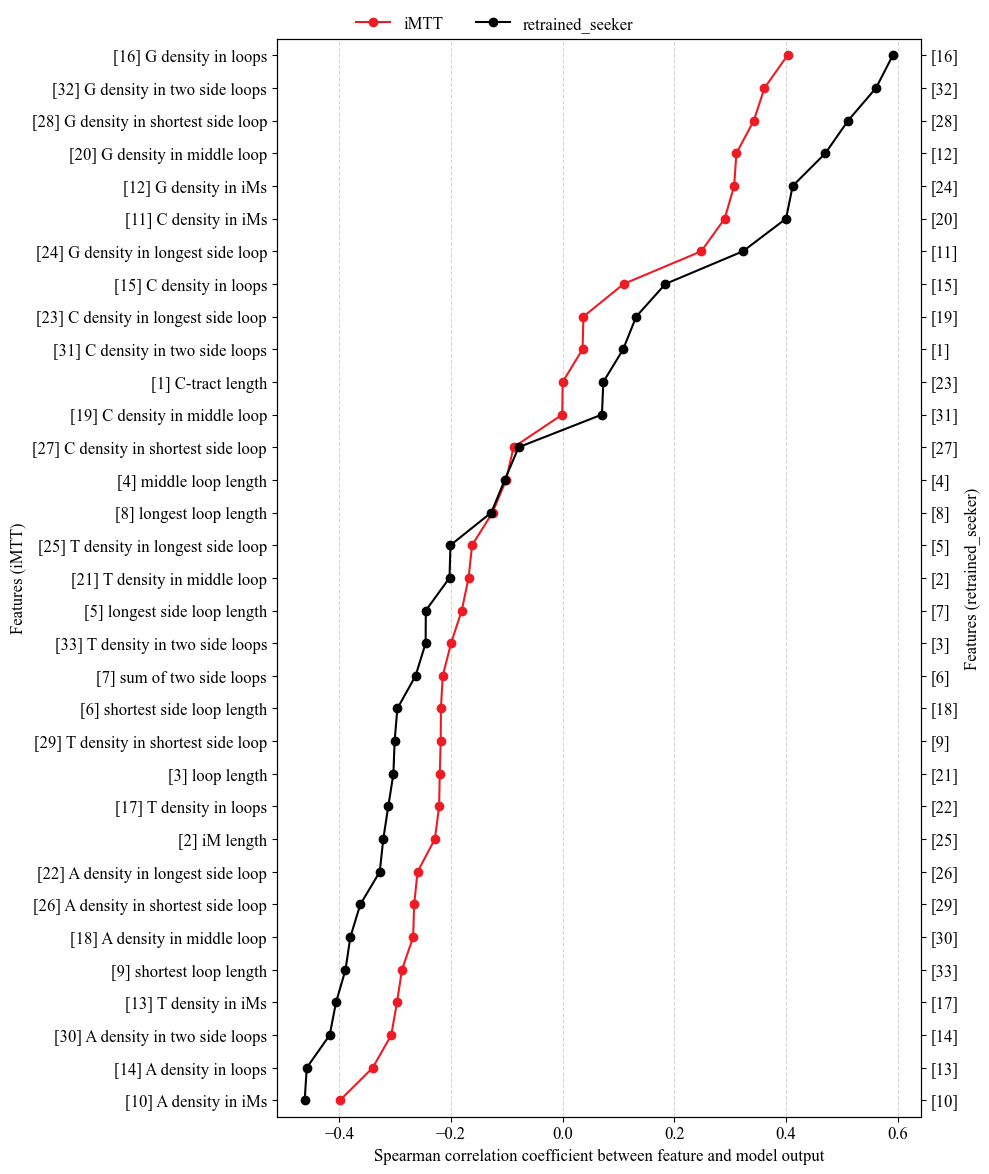

In [16]:
import matplotlib.pyplot as plt
# 读数据
imtt_model = pd.read_csv('imtt_importance.csv')
seeker_model = pd.read_csv('seeker_importance.csv')

# 设定重要性指标
importance_metric = 'spearman'

# 排序（各自按自己的spearman rho降序）
imtt_sorted = imtt_model.sort_values(importance_metric, ascending=True).reset_index(drop=True)
seeker_sorted = seeker_model.sort_values(importance_metric, ascending=True).reset_index(drop=True)
# print(seeker_sorted)

print(np.var(imtt_sorted[importance_metric]))
print(np.var(seeker_sorted[importance_metric]))

# 计算横轴的统一范围
rho_min = min(imtt_sorted[importance_metric].min(), seeker_sorted[importance_metric].min())-0.05
rho_max = max(imtt_sorted[importance_metric].max(), seeker_sorted[importance_metric].max())+0.05

# 画图
fig, ax_left = plt.subplots(figsize=(10, len(features33_names) * 0.35))
plt.rc('font', family='Times New Roman')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# 左轴：你的模型
line1, = ax_left.plot(imtt_sorted[importance_metric], range(len(features33_names)), marker='o', color='#ED1C24', label='Your Model')
ax_left.set_yticks(range(len(features33_names)))
ax_left.set_yticklabels(imtt_sorted['feature_name'], fontsize=12)
ax_left.set_ylabel('Features (iMTT)', fontsize=12)
ax_left.set_ylim(-0.5, 32.5)  # 设置横轴范围
ax_left.set_xlabel('Spearman correlation coefficient between feature and model output', fontsize=12)
ax_left.set_xlim(rho_min, rho_max)  # 设置横轴范围

temp_feats_names = [i.split(" ")[0] for i in seeker_sorted['feature_name']]
# 右图：seeker模型
ax_right = ax_left.twinx()
line2, = ax_right.plot(seeker_sorted[importance_metric], range(len(features33_names)), marker='o', color='black', label='seeker Model')
ax_right.set_yticks(range(len(features33_names)))
ax_right.set_yticklabels(temp_feats_names, fontsize=12)
ax_right.set_ylabel('Features (retrained_seeker)', fontsize=12)
ax_right.set_ylim(-0.5, 32.5)  # 设置横轴范围
ax_right.set_xlim(rho_min, rho_max)  # 右轴也同步设置横轴范围

fig.legend(handles=[line1, line2],
           labels=['iMTT', 'retrained_seeker'],
           loc='upper center', bbox_to_anchor=(0.5, 1.02),
           ncol=2, fontsize=12, frameon=False)

# 美化
# for spine in ['top', 'right', 'left', 'bottom']:
#     ax_left.spines[spine].set_visible(False)
#     ax_right.spines[spine].set_visible(False)

ax_left.grid(axis='x', linestyle='--', alpha=0.5)
ax_right.grid(axis='x', linestyle='--', alpha=0.5)


plt.tight_layout()
plt.savefig("../figures/33feats_importance_spearman.eps", format="eps", bbox_inches="tight")


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


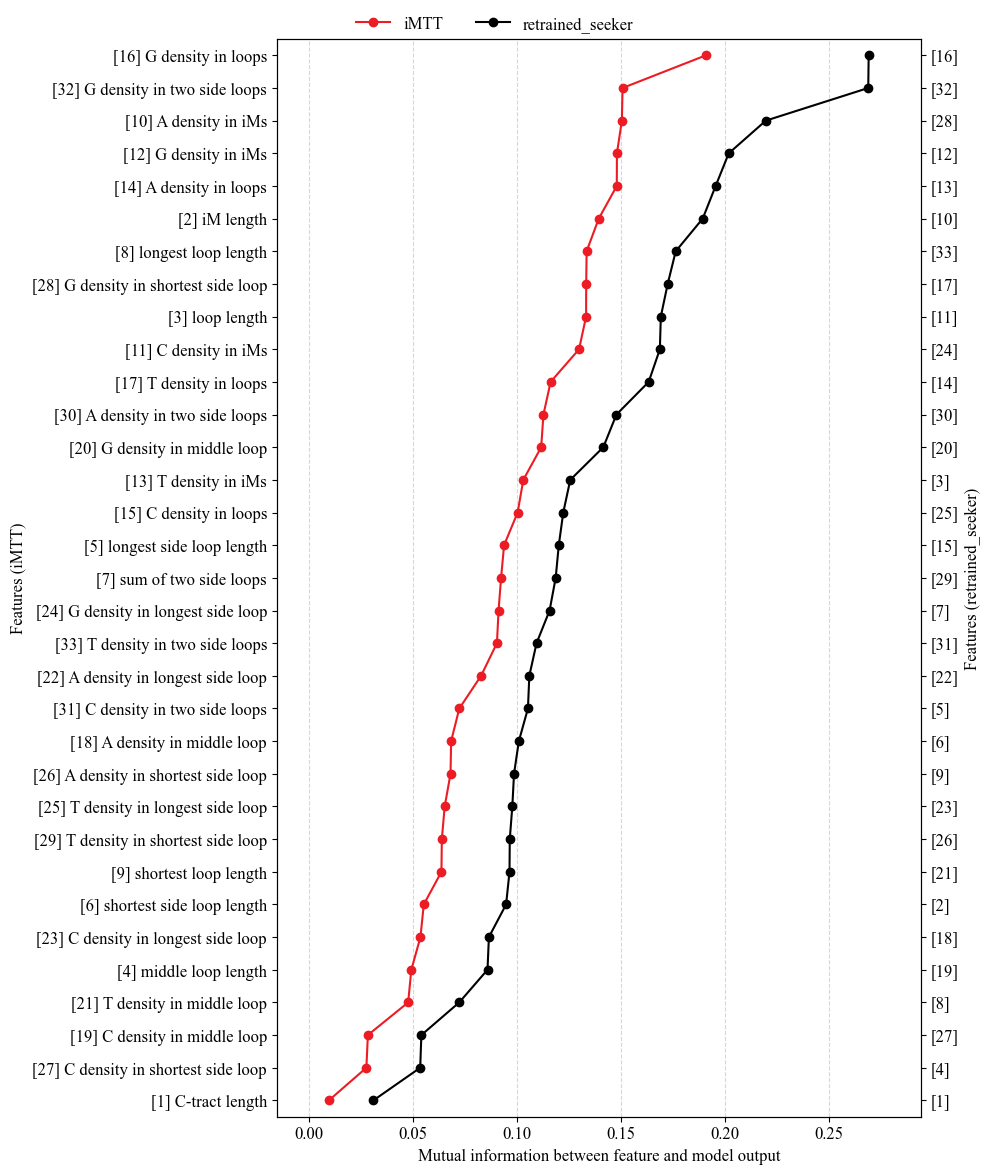

In [13]:
import matplotlib.pyplot as plt

# 读数据
imtt_model = pd.read_csv('imtt_importance.csv')
seeker_model = pd.read_csv('seeker_importance.csv')

# 设定重要性指标
importance_metric = 'mi'

# 排序（各自按自己的mi降序）
imtt_sorted = imtt_model.sort_values(importance_metric, ascending=True).reset_index(drop=True)
seeker_sorted = seeker_model.sort_values(importance_metric, ascending=True).reset_index(drop=True)
# print(seeker_sorted)

# 计算横轴的统一范围
rho_min = min(imtt_sorted[importance_metric].min(), seeker_sorted[importance_metric].min())-0.025
rho_max = max(imtt_sorted[importance_metric].max(), seeker_sorted[importance_metric].max())+0.025

# 画图
fig, ax_left = plt.subplots(figsize=(10, len(features33_names) * 0.35))
plt.rc('font', family='Times New Roman')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# 左轴：你的模型
line1, = ax_left.plot(imtt_sorted[importance_metric], range(len(features33_names)), marker='o', color='#ED1C24', label='Your Model')
ax_left.set_yticks(range(len(features33_names)))
ax_left.set_yticklabels(imtt_sorted['feature_name'], fontsize=12)
ax_left.set_ylabel('Features (iMTT)', fontsize=12)
ax_left.set_ylim(-0.5, 32.5)  # 设置横轴范围
ax_left.set_xlabel('Mutual information between feature and model output', fontsize=12)
ax_left.set_xlim(rho_min, rho_max)  # 设置横轴范围

temp_feats_names = [i.split(" ")[0] for i in seeker_sorted['feature_name']]
# 右图：seeker模型
ax_right = ax_left.twinx()
line2, = ax_right.plot(seeker_sorted[importance_metric], range(len(features33_names)), marker='o', color='black', label='seeker Model')
ax_right.set_yticks(range(len(features33_names)))
ax_right.set_yticklabels(temp_feats_names, fontsize=12)
ax_right.set_ylabel('Features (retrained_seeker)', fontsize=12)
ax_right.set_ylim(-0.5, 32.5)  # 设置横轴范围
ax_right.set_xlim(rho_min, rho_max)  # 右轴也同步设置横轴范围

fig.legend(handles=[line1, line2],
           labels=['iMTT', 'retrained_seeker'],
           loc='upper center', bbox_to_anchor=(0.5, 1.02),
           ncol=2, fontsize=12, frameon=False)

# 美化
# for spine in ['top', 'right', 'left', 'bottom']:
#     ax_left.spines[spine].set_visible(False)
#     ax_right.spines[spine].set_visible(False)

ax_left.grid(axis='x', linestyle='--', alpha=0.5)
ax_right.grid(axis='x', linestyle='--', alpha=0.5)


plt.tight_layout()
plt.savefig("../figures/33feats_importance_mi.eps", format="eps", bbox_inches="tight")
plt.savefig("../figures/33feats_importance_mi.svg", format="svg", bbox_inches="tight")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


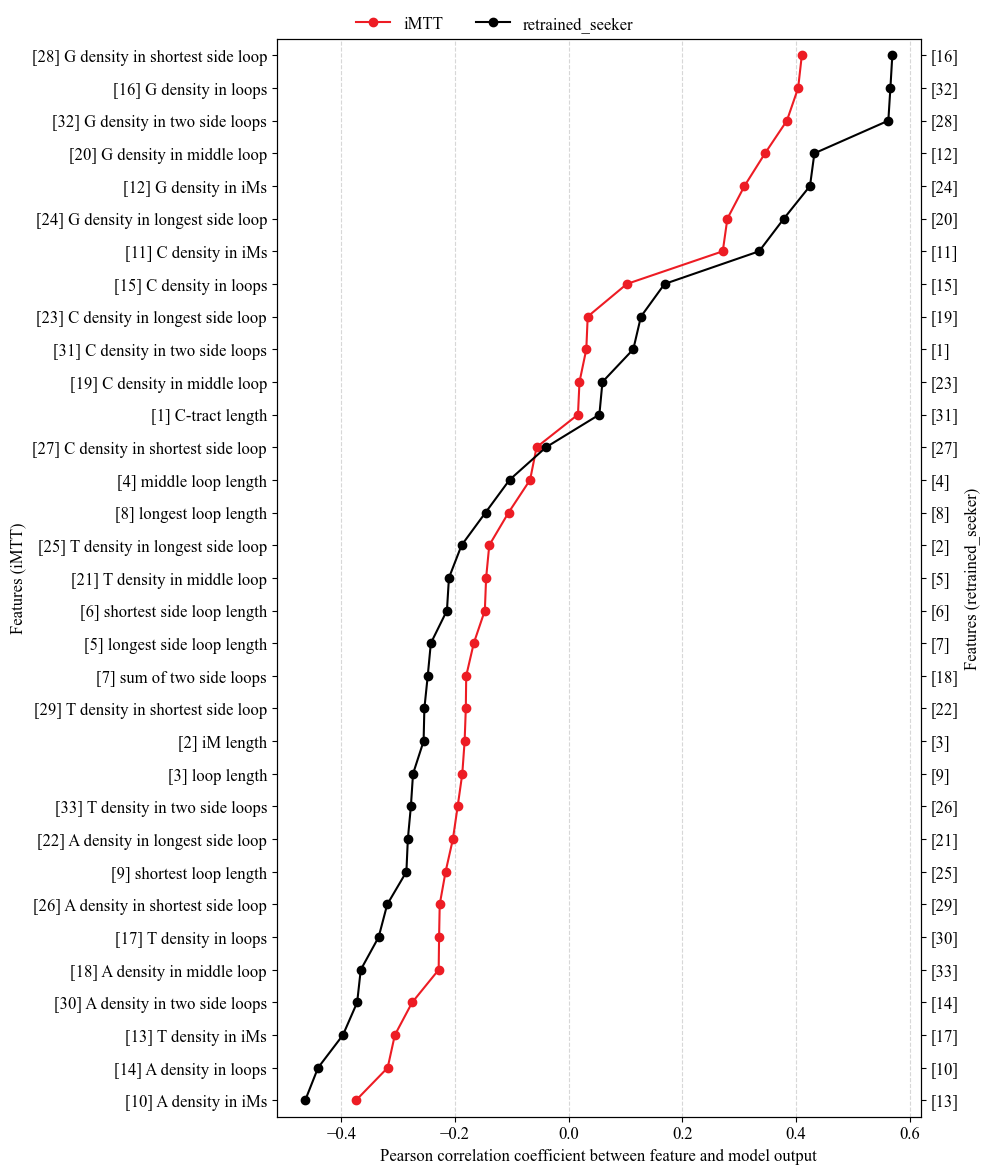

In [15]:
import matplotlib.pyplot as plt

# 读数据
imtt_model = pd.read_csv('imtt_importance.csv')
seeker_model = pd.read_csv('seeker_importance.csv')

# 设定重要性指标
importance_metric = 'pearson'

# 排序（各自按自己的pearson降序）
imtt_sorted = imtt_model.sort_values(importance_metric, ascending=True).reset_index(drop=True)
seeker_sorted = seeker_model.sort_values(importance_metric, ascending=True).reset_index(drop=True)
# print(seeker_sorted)

# 计算横轴的统一范围
rho_min = min(imtt_sorted[importance_metric].min(), seeker_sorted[importance_metric].min())-0.05
rho_max = max(imtt_sorted[importance_metric].max(), seeker_sorted[importance_metric].max())+0.05

# 画图
fig, ax_left = plt.subplots(figsize=(10, len(features33_names) * 0.35))
plt.rc('font', family='Times New Roman')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# 左轴：你的模型
line1, = ax_left.plot(imtt_sorted[importance_metric], range(len(features33_names)), marker='o', color='#ED1C24', label='Your Model')
ax_left.set_yticks(range(len(features33_names)))
ax_left.set_yticklabels(imtt_sorted['feature_name'], fontsize=12)
ax_left.set_ylabel('Features (iMTT)', fontsize=12)
ax_left.set_ylim(-0.5, 32.5)  # 设置横轴范围
ax_left.set_xlabel('Pearson correlation coefficient between feature and model output', fontsize=12)
ax_left.set_xlim(rho_min, rho_max)  # 设置横轴范围

temp_feats_names = [i.split(" ")[0] for i in seeker_sorted['feature_name']]
# 右图：seeker模型
ax_right = ax_left.twinx()
line2, = ax_right.plot(seeker_sorted[importance_metric], range(len(features33_names)), marker='o', color='black', label='seeker Model')
ax_right.set_yticks(range(len(features33_names)))
ax_right.set_yticklabels(temp_feats_names, fontsize=12)
ax_right.set_ylabel('Features (retrained_seeker)', fontsize=12)
ax_right.set_ylim(-0.5, 32.5)  # 设置横轴范围
ax_right.set_xlim(rho_min, rho_max)  # 右轴也同步设置横轴范围

fig.legend(handles=[line1, line2],
           labels=['iMTT', 'retrained_seeker'],
           loc='upper center', bbox_to_anchor=(0.5, 1.02),
           ncol=2, fontsize=12, frameon=False)

# 美化
# for spine in ['top', 'right', 'left', 'bottom']:
#     ax_left.spines[spine].set_visible(False)
#     ax_right.spines[spine].set_visible(False)

ax_left.grid(axis='x', linestyle='--', alpha=0.5)
ax_right.grid(axis='x', linestyle='--', alpha=0.5)


plt.tight_layout()
plt.savefig("../figures/33feats_importance_pearson.eps", format="eps", bbox_inches="tight")
plt.savefig("../figures/33feats_importance_pearson.svg", format="svg", bbox_inches="tight")